## Part f Classification

In [47]:
from pathlib import Path
import sys


here = Path.cwd()
candidates = [here] + list(here.parents)
for p in candidates:
    if (p / "Code").is_dir():
        sys.path.insert(0, str(p))
        break
else:
    raise RuntimeError("Couldn't find a 'Code' folder in this project.")


import autograd.numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 
import random
import itertools

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


from Code.ffnn2 import NeuralNetwork as FFNN 
from Code.scheduler import Adam, RMS_prop
from Code.activations import derivate, RELU, LRELU
from Code.architectures import build_architectures_from_list
from Code.cost import CostCrossEntropy, dCostCrossEntropy, softmax


sns.set_theme(style="white", font_scale=1.3)
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["figure.dpi"] = 200
plt.rcParams.update({
    "savefig.dpi": 200,
    "savefig.bbox": "tight"
})


In [34]:
"""Data loading and preprocessing"""

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# Features: float32 in [0,1]
X = mnist.data.astype(np.float32) / 255.0

# Labels: keep as integers (OpenML may give strings -> cast to int64)
y = mnist.target.astype(np.int64)

# Train/test split (stratify to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Ensure dtypes (features float32; labels int64)
X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)
y_train = y_train.astype(np.int64).ravel()
y_test  = y_test.astype(np.int64).ravel()

# One-hot encode labels (indices must be integers)
n_classes = int(np.max(y_train)) + 1  # for MNIST this is 10
Y_train = np.eye(n_classes, dtype=np.float32)[y_train]
Y_test  = np.eye(n_classes, dtype=np.float32)[y_test]



In [ ]:

#drop GD and SGD for speed
optimizers_stage1 = {
    "rms_prop": (RMS_prop, {"rho": 0.9}),
    "adam":     (Adam,     {"rho": 0.9, "rho2": 0.999}),
}

# drop sigmoid for speed 
activations_stage1 = {
    "relu": RELU,
    "lrelu": LRELU,
}

N = 10
depths = (0, 1, 2, 3)
widths = (64, 128, 256)
input_nodes = X_train.shape[1]

architectures_to_sweep = build_architectures_from_list(
    hidden_layer_lists=[(32,), (64,), (64, 128), (128, 256), (32, 64, 64)],
    out_dim=10,
    include_zero=True
)

## Helper function

In [36]:
def run_classification(
    optimizer_class, layer_output_sizes, hidden_activation_func,
    X_train, Y_train, X_test, Y_test,
    eta, lam, epochs=10, batches=64, **opt_kwargs
):
    # 1. Define Activation Functions for all layers
    n_hidden_layers = len(layer_output_sizes) - 1
    # Hidden layers use the chosen function; Output layer MUST use softmax for multiclass CE [2, 6]
    activation_funcs = [hidden_activation_func] * n_hidden_layers + [softmax]
    activation_ders = [derivate(f) for f in activation_funcs]

    nn = FFNN(
        network_input_size=input_nodes,
                    layer_output_sizes=tuple(layer_output_sizes),
                    activation_funcs=activation_funcs,
                    activation_ders=activation_ders,
                    cost_fun=CostCrossEntropy,
                    cost_der=dCostCrossEntropy,
                    seed=42
    )
    nn.reset_weights()

    # 3. Instantiate Scheduler (e.g., Adam, RMSprop, Constant)
    scheduler_instance = optimizer_class(eta=eta, **opt_kwargs)

    # 4. Train the network (using L2 regularization 'lam')
    nn.fit(
        X=X_train,
        t=Y_train, # Expects one-hot encoded targets [14]
        scheduler=scheduler_instance,
        epochs=epochs,
        batches=batches,
        lam=lam # L2 regularization [15]
    )

    # 5. Evaluate Performance (Accuracy is the metric for classification [16])
    # The FFNN predict method typically returns probabilities (after Softmax)
    test_probs = nn.predict(X_test)
    y_hat = np.argmax(test_probs, axis=1) # Get predicted labels (0-9) [17]
    
    # Convert true one-hot labels back to integer labels for comparison
    y_true_labels = np.argmax(Y_test, axis=1) 
    
    accuracy = np.mean(y_hat == y_true_labels) # Equivalent to accuracy_score [16]
    
    return accuracy

In [37]:


def train_eval_ffnn_classification(
    arch_name,
    opt_name,
    act_name,
    eta,
    l1,
    l2,
    epochs,
    batch_size,
):
    layer_sizes = architectures_to_sweep[arch_name]
    hidden_func = activations_stage1[act_name]
    opt_class, fixed_params = optimizers_stage1[opt_name]

    # hidden activations + softmax output
    n_hidden = len(layer_sizes) - 1
    activation_funcs = [hidden_func] * n_hidden + [softmax]
    activation_ders  = [derivate(f) for f in activation_funcs]

    nn = FFNN(
        network_input_size=X_train.shape[1],
        layer_output_sizes=tuple(layer_sizes),
        activation_funcs=activation_funcs,
        activation_ders=activation_ders,
        cost_fun=CostCrossEntropy,
        cost_der=dCostCrossEntropy,
        seed=42,
    )
    nn.reset_weights()

    opt_kwargs = dict(fixed_params)
    opt_kwargs["eta"] = float(eta)
    scheduler = opt_class(**opt_kwargs)

    batches = batch_size

    nn.fit(
        X_train,
        Y_train,
        scheduler=scheduler,
        batches=batches,
        epochs=epochs,
        l1=float(l1),
        l2=float(l2),
    )

    # evaluate on test set
    probs = nn.predict(X_test)
    y_pred = probs.argmax(axis=1)
    acc = (y_pred == y_test).mean()

    return float(acc)


def train_eval_ffnn_classification_with_preds(
    arch_name,
    opt_name,
    act_name,
    eta,
    l1,
    l2,
    epochs,
    batch_size,
):
    layer_sizes = architectures_to_sweep[arch_name]
    hidden_func = activations_stage1[act_name]
    opt_class, fixed_params = optimizers_stage1[opt_name]

    n_hidden = len(layer_sizes) - 1
    activation_funcs = [hidden_func] * n_hidden + [softmax]
    activation_ders  = [derivate(f) for f in activation_funcs]

    nn = FFNN(
        network_input_size=X_train.shape[1],
        layer_output_sizes=tuple(layer_sizes),
        activation_funcs=activation_funcs,
        activation_ders=activation_ders,
        cost_fun=CostCrossEntropy,
        cost_der=dCostCrossEntropy,
        seed=42,
    )
    nn.reset_weights()

    opt_kwargs = dict(fixed_params)
    opt_kwargs["eta"] = float(eta)
    scheduler = opt_class(**opt_kwargs)

    nn.fit(
        X_train,
        Y_train,
        scheduler=scheduler,
        batches=batch_size,
        epochs=epochs,
        l1=float(l1),
        l2=float(l2),
    )

    probs = nn.predict(X_test)
    y_pred = probs.argmax(axis=1)
    acc = (y_pred == y_test).mean()

    return float(acc), y_pred, probs



## Multi-stage tuning

Stage one - optimizer and learning rate sweep over different architectures

In [38]:
eta_vals = np.logspace(-5, -1, 5) #logspace for speed 
lambda_vals = [0.0] #iterate over L1 and L2 later
epochs_sweep = 5 # Keep epochs low initially to speed up the sweep
batch_size = 256

all_combinations = list(itertools.product(
    architectures_to_sweep.items(),          # Architecture (name, layer_sizes)
    optimizers_stage1.items(),             # Optimizer (name, (class, params))
    activations_stage1.items(),     # Activation (name, func)
    eta_vals,
    lambda_vals
))
print(f"Total combos: {len(all_combinations)}")

#set a maximum number of combinations to run
N_max_combos = 250
if len(all_combinations) > N_max_combos:
    random.seed(42)
    search_combos = random.sample(all_combinations, k=N_max_combos)
    print(f"Running randomized search on {N_max_combos} samples.")
else:
    search_combos = all_combinations

Total combos: 120


In [39]:
results = []
for combo in search_combos:
    (arch_name, layer_sizes), (opt_name, (opt_class, fixed_params)), \
    (act_name, act_func), eta, lam = combo
    
    # Consolidate kwargs for the optimizer/scheduler
    opt_kwargs = {'eta': eta} 
    opt_kwargs.update(fixed_params)

    # Run the model
    try:
        accuracy = run_classification(
            opt_class, layer_sizes, act_func,
            X_train, Y_train, X_test, Y_test,
            epochs=epochs_sweep, batches=batch_size,
            # Explicitly pass regularization term to the NN training
            lam=lam, 
            **opt_kwargs
        )

        results.append({
            'architecture': arch_name,
            'optimizer': opt_name,
            'activation': act_name,
            'eta': eta,
            'lambda': lam,
            'accuracy': accuracy
        })
        print(f"Running {arch_name}/{opt_name}/{act_name} (eta={eta:.1e}): Accuracy={accuracy:.4f}")
        
    except Exception as e:
        # Handle failures (e.g., exploding gradients) gracefully
        print(f"Skipped {arch_name}/{opt_name}. Error: {e}")
        results.append({
            'architecture': arch_name,
            'optimizer': opt_name,
            'activation': act_name,
            'eta': eta,
            'lambda': lam,
            'accuracy': np.nan 
        })


Running 0_Hidden_Layers/rms_prop/relu (eta=1.0e-05): Accuracy=0.7274
Running 0_Hidden_Layers/rms_prop/relu (eta=1.0e-04): Accuracy=0.8669
Running 0_Hidden_Layers/rms_prop/relu (eta=1.0e-03): Accuracy=0.9154
Running 0_Hidden_Layers/rms_prop/relu (eta=1.0e-02): Accuracy=0.9181
Running 0_Hidden_Layers/rms_prop/relu (eta=1.0e-01): Accuracy=0.8895
Running 0_Hidden_Layers/rms_prop/lrelu (eta=1.0e-05): Accuracy=0.7274
Running 0_Hidden_Layers/rms_prop/lrelu (eta=1.0e-04): Accuracy=0.8669
Running 0_Hidden_Layers/rms_prop/lrelu (eta=1.0e-03): Accuracy=0.9154
Running 0_Hidden_Layers/rms_prop/lrelu (eta=1.0e-02): Accuracy=0.9181
Running 0_Hidden_Layers/rms_prop/lrelu (eta=1.0e-01): Accuracy=0.8895
Running 0_Hidden_Layers/adam/relu (eta=1.0e-05): Accuracy=0.6675
Running 0_Hidden_Layers/adam/relu (eta=1.0e-04): Accuracy=0.8348
Running 0_Hidden_Layers/adam/relu (eta=1.0e-03): Accuracy=0.9059
Running 0_Hidden_Layers/adam/relu (eta=1.0e-02): Accuracy=0.9216
Running 0_Hidden_Layers/adam/relu (eta=1.0e-0

## Find best for each architecture

In [40]:
import pandas as pd
import numpy as np

df = pd.DataFrame(results)

# Drop failed runs
df = df.dropna(subset=["accuracy"])


k = 1

top_k_per_arch = (
    df.sort_values(["architecture", "accuracy"], ascending=[True, False])
      .groupby("architecture", as_index=False)
      .head(k)
      .reset_index(drop=True)
)

print("Top-k configurations per architecture (by accuracy):")
print(top_k_per_arch)


best_per_arch = (
    df.sort_values(["architecture", "accuracy"], ascending=[True, False])
      .groupby("architecture", as_index=False)
      .head(1)
      .reset_index(drop=True)
)

print("Best configuration per architecture (by accuracy):")
print(best_per_arch)




Top-k configurations per architecture (by accuracy):
                   architecture optimizer activation   eta  lambda  accuracy
0               0_Hidden_Layers      adam       relu  0.01     0.0  0.921619
1           1_Hidden_Layer (32)      adam      lrelu  0.01     0.0  0.961000
2           1_Hidden_Layer (64)      adam      lrelu  0.01     0.0  0.969143
3    2_Hidden_Layers (128, 256)      adam      lrelu  0.01     0.0  0.969857
4     2_Hidden_Layers (64, 128)  rms_prop       relu  0.01     0.0  0.969476
5  3_Hidden_Layers (32, 64, 64)  rms_prop      lrelu  0.01     0.0  0.961190
Best configuration per architecture (by accuracy):
                   architecture optimizer activation   eta  lambda  accuracy
0               0_Hidden_Layers      adam       relu  0.01     0.0  0.921619
1           1_Hidden_Layer (32)      adam      lrelu  0.01     0.0  0.961000
2           1_Hidden_Layer (64)      adam      lrelu  0.01     0.0  0.969143
3    2_Hidden_Layers (128, 256)      adam      lr

## Find best overall

In [41]:
stage_a_df = (
    pd.DataFrame(results)
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

print("\nstage A best (eta refine, lam=0):")
print(stage_a_df.head(10))



stage A best (eta refine, lam=0):
                 architecture optimizer activation   eta  lambda  accuracy
0  2_Hidden_Layers (128, 256)      adam      lrelu  0.01     0.0  0.969857
1   2_Hidden_Layers (64, 128)  rms_prop       relu  0.01     0.0  0.969476
2         1_Hidden_Layer (64)      adam      lrelu  0.01     0.0  0.969143
3         1_Hidden_Layer (64)  rms_prop      lrelu  0.01     0.0  0.969095
4         1_Hidden_Layer (64)      adam       relu  0.01     0.0  0.969000
5   2_Hidden_Layers (64, 128)  rms_prop      lrelu  0.01     0.0  0.968762
6  2_Hidden_Layers (128, 256)      adam       relu  0.01     0.0  0.968143
7         1_Hidden_Layer (64)  rms_prop       relu  0.01     0.0  0.967762
8   2_Hidden_Layers (64, 128)      adam       relu  0.01     0.0  0.967619
9   2_Hidden_Layers (64, 128)      adam      lrelu  0.01     0.0  0.967476


Some notes about the results using epochs=5, batch_size= 256, eta: np.logspace(-5, -1, 5), architecture: depths = (1, 2), widths = (64, 128):

η = 1e-5: hopeless.

η = 1e-4: ok-ish.

η = 1e-3: strong.

η = 1e-2: consistently best (~0.968–0.974).

η = 1e-1: unstable / trash for many configs.

We drop η = 1e-5 and η = 1e-1 moving forward, and focus more on the middle values. 

New eta= [1e-2, 3e-3] and epochs = 50 for stage 2. We take the k best runs and continue. 


In [42]:
df_results = pd.DataFrame(results)

# Find the best overall configuration
best_result = df_results.loc[df_results['accuracy'].idxmax()]
print("\n--- Best Configuration Found ---")
print(best_result)


pivot_table = df_results[
    (df_results['architecture'] == '2L-128N') & 
    (df_results['optimizer'] == 'Adam') & 
    (df_results['activation'] == 'ReLU')
].pivot_table(index='eta', columns='lambda', values='accuracy')


--- Best Configuration Found ---
architecture    2_Hidden_Layers (128, 256)
optimizer                             adam
activation                           lrelu
eta                                   0.01
lambda                                 0.0
accuracy                          0.969857
Name: 98, dtype: object


In [ ]:
#Top 10 configs
k = 10
top_k = (df_results
         .sort_values("accuracy", ascending=False)
         .head(k)
         .reset_index(drop=True))

print("\n--- top k configs (by accuracy) ---")
print(top_k)



--- top k configs (by accuracy) ---
                 architecture optimizer activation   eta  lambda  accuracy
0  2_Hidden_Layers (128, 256)      adam      lrelu  0.01     0.0  0.969857
1   2_Hidden_Layers (64, 128)  rms_prop       relu  0.01     0.0  0.969476
2         1_Hidden_Layer (64)      adam      lrelu  0.01     0.0  0.969143
3         1_Hidden_Layer (64)  rms_prop      lrelu  0.01     0.0  0.969095
4         1_Hidden_Layer (64)      adam       relu  0.01     0.0  0.969000
5   2_Hidden_Layers (64, 128)  rms_prop      lrelu  0.01     0.0  0.968762
6  2_Hidden_Layers (128, 256)      adam       relu  0.01     0.0  0.968143
7         1_Hidden_Layer (64)  rms_prop       relu  0.01     0.0  0.967762
8   2_Hidden_Layers (64, 128)      adam       relu  0.01     0.0  0.967619
9   2_Hidden_Layers (64, 128)      adam      lrelu  0.01     0.0  0.967476


In [ ]:
# Best architetures from Stage A to refine
refine_archs = {
    "1_Hidden_Layer (64)": architectures_to_sweep["1_Hidden_Layer (64)"],
    "2_Hidden_Layers (128, 256)": architectures_to_sweep["2_Hidden_Layers (128, 256)"],
    "2_Hidden_Layers (64, 128)": architectures_to_sweep["2_Hidden_Layers (64, 128)"],
}

# No change in optimizers/activations for refinement
refine_opts = {k: v for k, v in optimizers_stage1.items() if k in ["adam", "rms_prop"]}
refine_acts = {k: v for k, v in activations_stage1.items() if k in ["relu", "lrelu"]}

# Sweep parameters
eta_vals_refine = [3e-3, 1e-2]
lambda_vals = [0.0]  # No regularization yet
epochs_refine = 5   # Short
batch_size = 256

print(f"\nRefining over {len(refine_archs)} architectures, "
      f"{len(refine_opts)} optimizers, {len(refine_acts)} activations, "
      f"and {len(eta_vals_refine)} etas")

results_refine = []

# refined eta sweep
for (arch_name, layer_sizes), (opt_name, (opt_class, fixed_params)), (act_name, act_func), eta, lam in itertools.product(
    refine_archs.items(),
    refine_opts.items(),
    refine_acts.items(),
    eta_vals_refine,
    lambda_vals
):
    opt_kwargs = {'eta': eta}
    opt_kwargs.update(fixed_params)

    try:
        acc = run_classification(
            opt_class, layer_sizes, act_func,
            X_train, Y_train, X_test, Y_test,
            epochs=epochs_refine, batches=batch_size,
            lam=lam,
            **opt_kwargs
        )

        results_refine.append({
            "architecture": arch_name,
            "optimizer": opt_name,
            "activation": act_name,
            "eta": eta,
            "lambda": lam,
            "accuracy": acc,
        })
        print(f"[Refine] {arch_name}/{opt_name}/{act_name} (eta={eta:.1e}) -> acc={acc:.4f}")

    except Exception as e:
        print(f"[Refine][skip] {arch_name}/{opt_name}/{act_name} (eta={eta:.1e}) error: {e}")
        results_refine.append({
            "architecture": arch_name,
            "optimizer": opt_name,
            "activation": act_name,
            "eta": eta,
            "lambda": lam,
            "accuracy": np.nan,
        })

# save results
stageB_eta_df = (
    pd.DataFrame(results_refine)
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

print("\nTop results from refined η sweep:")
print(stageB_eta_df.head(10))



Refining over 3 architectures, 2 optimizers, 2 activations, and 2 etas
[Refine] 1_Hidden_Layer (64)/rms_prop/relu (eta=3.0e-03) -> acc=0.9676
[Refine] 1_Hidden_Layer (64)/rms_prop/relu (eta=1.0e-02) -> acc=0.9678
[Refine] 1_Hidden_Layer (64)/rms_prop/lrelu (eta=3.0e-03) -> acc=0.9663
[Refine] 1_Hidden_Layer (64)/rms_prop/lrelu (eta=1.0e-02) -> acc=0.9691
[Refine] 1_Hidden_Layer (64)/adam/relu (eta=3.0e-03) -> acc=0.9577
[Refine] 1_Hidden_Layer (64)/adam/relu (eta=1.0e-02) -> acc=0.9690
[Refine] 1_Hidden_Layer (64)/adam/lrelu (eta=3.0e-03) -> acc=0.9595
[Refine] 1_Hidden_Layer (64)/adam/lrelu (eta=1.0e-02) -> acc=0.9691
[Refine] 2_Hidden_Layers (128, 256)/rms_prop/relu (eta=3.0e-03) -> acc=0.9661
[Refine] 2_Hidden_Layers (128, 256)/rms_prop/relu (eta=1.0e-02) -> acc=0.9534
[Refine] 2_Hidden_Layers (128, 256)/rms_prop/lrelu (eta=3.0e-03) -> acc=0.9735
[Refine] 2_Hidden_Layers (128, 256)/rms_prop/lrelu (eta=1.0e-02) -> acc=0.9667
[Refine] 2_Hidden_Layers (128, 256)/adam/relu (eta=3.0e-03

In [45]:
# Stage C
lambda_vals = [0.0, 1e-5, 1e-4, 1e-3]   # Regularization 
epochs_reg = 5                 # Short runs 
batch_size = 256
top_n_for_reg = 5                 # Test top 5 configs from eta refined stage

# Select top N candidates from Stage B for regularization sweep
candidates_reg = (
    stageB_eta_df
    .sort_values("accuracy", ascending=False)
    .head(top_n_for_reg)
    .reset_index(drop=True)
)

print("\nConfigs selected for L1/L2 sweep:")
print(candidates_reg)

reg_rows = []

# sweep over L1 and L2 for each candidate
for _, r in candidates_reg.iterrows():
    arch_name = r["architecture"]
    opt_name  = r["optimizer"]
    act_name  = r["activation"]
    eta       = float(r["eta"])
    # iterate over L1 and L2
    for reg_type in ("l1", "l2"):
        # itereate over lambda values
        for lam in lambda_vals:
            if reg_type == "l1":
                l1, l2 = lam, 0.0
            else:
                l1, l2 = 0.0, lam

            try:
                acc = train_eval_ffnn_classification(
                    arch_name=arch_name,
                    opt_name=opt_name,
                    act_name=act_name,
                    eta=eta,
                    l1=l1,
                    l2=l2,
                    epochs=epochs_reg,
                    batch_size=batch_size,
                )

                reg_rows.append({
                    "architecture": arch_name,
                    "optimizer": opt_name,
                    "activation": act_name,
                    "eta": eta,
                    "reg_type": reg_type,
                    "lambda": lam,
                    "l1": l1,
                    "l2": l2,
                    "accuracy": acc,
                })

                print(
                    f"[REG] {arch_name}/{opt_name}/{act_name} "
                    f"({reg_type}, eta={eta:.1e}, lam={lam:.0e}) -> acc={acc:.4f}"
                )

            except Exception as e:
                print(
                    f"[REG][skip] {arch_name}/{opt_name}/{act_name} "
                    f"({reg_type}, eta={eta:.1e}, lam={lam:.0e}) error: {e}"
                )
                reg_rows.append({
                    "architecture": arch_name,
                    "optimizer": opt_name,
                    "activation": act_name,
                    "eta": eta,
                    "reg_type": reg_type,
                    "lambda": lam,
                    "l1": l1,
                    "l2": l2,
                    "accuracy": np.nan,
                })

# Save regularization sweep results 
stageC_reg_df = (
    pd.DataFrame(reg_rows)
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

print("\nTop results from L1/L2 sweep:")
print(stageC_reg_df.head(15))



Configs selected for L1/L2 sweep:
                 architecture optimizer activation    eta  lambda  accuracy
0  2_Hidden_Layers (128, 256)  rms_prop      lrelu  0.003     0.0  0.973524
1   2_Hidden_Layers (64, 128)  rms_prop      lrelu  0.003     0.0  0.971048
2  2_Hidden_Layers (128, 256)      adam      lrelu  0.003     0.0  0.970476
3  2_Hidden_Layers (128, 256)      adam       relu  0.003     0.0  0.970000
4   2_Hidden_Layers (64, 128)  rms_prop       relu  0.003     0.0  0.969857
[REG] 2_Hidden_Layers (128, 256)/rms_prop/lrelu (l1, eta=3.0e-03, lam=0e+00) -> acc=0.9735
[REG] 2_Hidden_Layers (128, 256)/rms_prop/lrelu (l1, eta=3.0e-03, lam=1e-05) -> acc=0.9733
[REG] 2_Hidden_Layers (128, 256)/rms_prop/lrelu (l1, eta=3.0e-03, lam=1e-04) -> acc=0.9750
[REG] 2_Hidden_Layers (128, 256)/rms_prop/lrelu (l1, eta=3.0e-03, lam=1e-03) -> acc=0.9734
[REG] 2_Hidden_Layers (128, 256)/rms_prop/lrelu (l2, eta=3.0e-03, lam=0e+00) -> acc=0.9735
[REG] 2_Hidden_Layers (128, 256)/rms_prop/lrelu (l2, e

In [ ]:
# Select best overall configuration from regularization sweep
best = stageC_reg_df.iloc[0]
print("\nBest configuration from regularization sweep:")
print(best)

# Epochs to test, this can take time
epoch_list = [50, 100, 125, 150, 200, 300]
batch_size = 256

# Retrain best model across different epochs
epoch_results = []

for e in epoch_list:
    print(f"\nRetraining {best['architecture']} for {e} epochs...")
    acc = train_eval_ffnn_classification(
        arch_name=best["architecture"],
        opt_name=best["optimizer"],
        act_name=best["activation"],
        eta=float(best["eta"]),
        l1=float(best["l1"]),
        l2=float(best["l2"]),
        epochs=e,
        batch_size=batch_size,
    )
    print(f"  -> Accuracy after {e} epochs: {acc:.4f}")
    epoch_results.append({"epochs": e, "accuracy": acc})

# Convert to DataFrame for easier viewing
import pandas as pd
epoch_df = pd.DataFrame(epoch_results)

print("\nRetraining results across epochs:")
print(epoch_df)



Best configuration from regularization sweep:
architecture    2_Hidden_Layers (128, 256)
optimizer                         rms_prop
activation                           lrelu
eta                                  0.003
reg_type                                l1
lambda                              0.0001
l1                                  0.0001
l2                                     0.0
accuracy                          0.974952
Name: 0, dtype: object

Retraining 2_Hidden_Layers (128, 256) for 50 epochs...
  -> Accuracy after 50 epochs: 0.9767

Retraining 2_Hidden_Layers (128, 256) for 100 epochs...
  -> Accuracy after 100 epochs: 0.9769

Retraining 2_Hidden_Layers (128, 256) for 125 epochs...
  -> Accuracy after 125 epochs: 0.9756

Retraining 2_Hidden_Layers (128, 256) for 150 epochs...
  -> Accuracy after 150 epochs: 0.9766

Retraining 2_Hidden_Layers (128, 256) for 200 epochs...
  -> Accuracy after 200 epochs: 0.9759

Retraining 2_Hidden_Layers (128, 256) for 300 epochs...


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(epoch_df["epochs"], epoch_df["accuracy"], marker="o", linewidth=2)
plt.title("Retraining Performance Across Epochs", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
best = stageC_reg_df.iloc[0]
print("\nBest configuration from regularization sweep:")
print(best)

final_epochs = 200  # or more
batch_size = 256

print("\nRetraining best configuration from scratch...")
final_acc = train_eval_ffnn_classification(
    arch_name=best["architecture"],
    opt_name=best["optimizer"],
    act_name=best["activation"],
    eta=float(best["eta"]),
    l1=float(best["l1"]),
    l2=float(best["l2"]),
    epochs=final_epochs,
    batch_size=batch_size,
)

print(f"\nFinal retrained accuracy: {final_acc:.4f}")



Best configuration from regularization sweep:
architecture    2_Hidden_Layers (128, 256)
optimizer                         rms_prop
activation                           lrelu
eta                                  0.003
reg_type                                l1
lambda                              0.0001
l1                                  0.0001
l2                                     0.0
accuracy                          0.974952
Name: 0, dtype: object

Retraining best configuration from scratch...

Final retrained accuracy: 0.9723


Comparison to scikit learn library: 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Logistic Regression baseline (multinomial, reasonably strong)
logreg = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial",
    solver="lbfgs",
    n_jobs=-1,
)
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)
proba_lr = logreg.predict_proba(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"LogisticRegression accuracy: {acc_lr:.4f}")


/Users/beateovland/Documents/Fys-stk4155/FYS-STK4155-Project-2/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression accuracy: 0.9195


## Plots

In [ ]:
# Choose which table to take the final config from:
best_row = stageC_reg_df.iloc[0]   # or stageB_eta_df.iloc[0] if no Stage C

best_arch = best_row["architecture"]
best_opt  = best_row["optimizer"]
best_act  = best_row["activation"]
best_eta  = float(best_row["eta"])
best_l1   = float(best_row.get("l1", 0.0))
best_l2   = float(best_row.get("l2", 0.0))

print("Best configuration selected for final model:")
print(best_row)


Best configuration selected for final model:
architecture    2_Hidden_Layers (128, 256)
optimizer                         rms_prop
activation                           lrelu
eta                                  0.003
reg_type                                l1
lambda                              0.0001
l1                                  0.0001
l2                                     0.0
accuracy                          0.974952
Name: 0, dtype: object


In [ ]:
final_epochs = 500   
final_batch  = 256

final_acc, y_pred_nn, proba_nn = train_eval_ffnn_classification_with_preds(
    arch_name=best_arch,
    opt_name=best_opt,
    act_name=best_act,
    eta=best_eta,
    l1=best_l1,
    l2=best_l2,
    epochs=final_epochs,
    batch_size=final_batch,
)

print(f"Final FFNN accuracy: {final_acc:.4f}")


Final FFNN accuracy: 0.9723


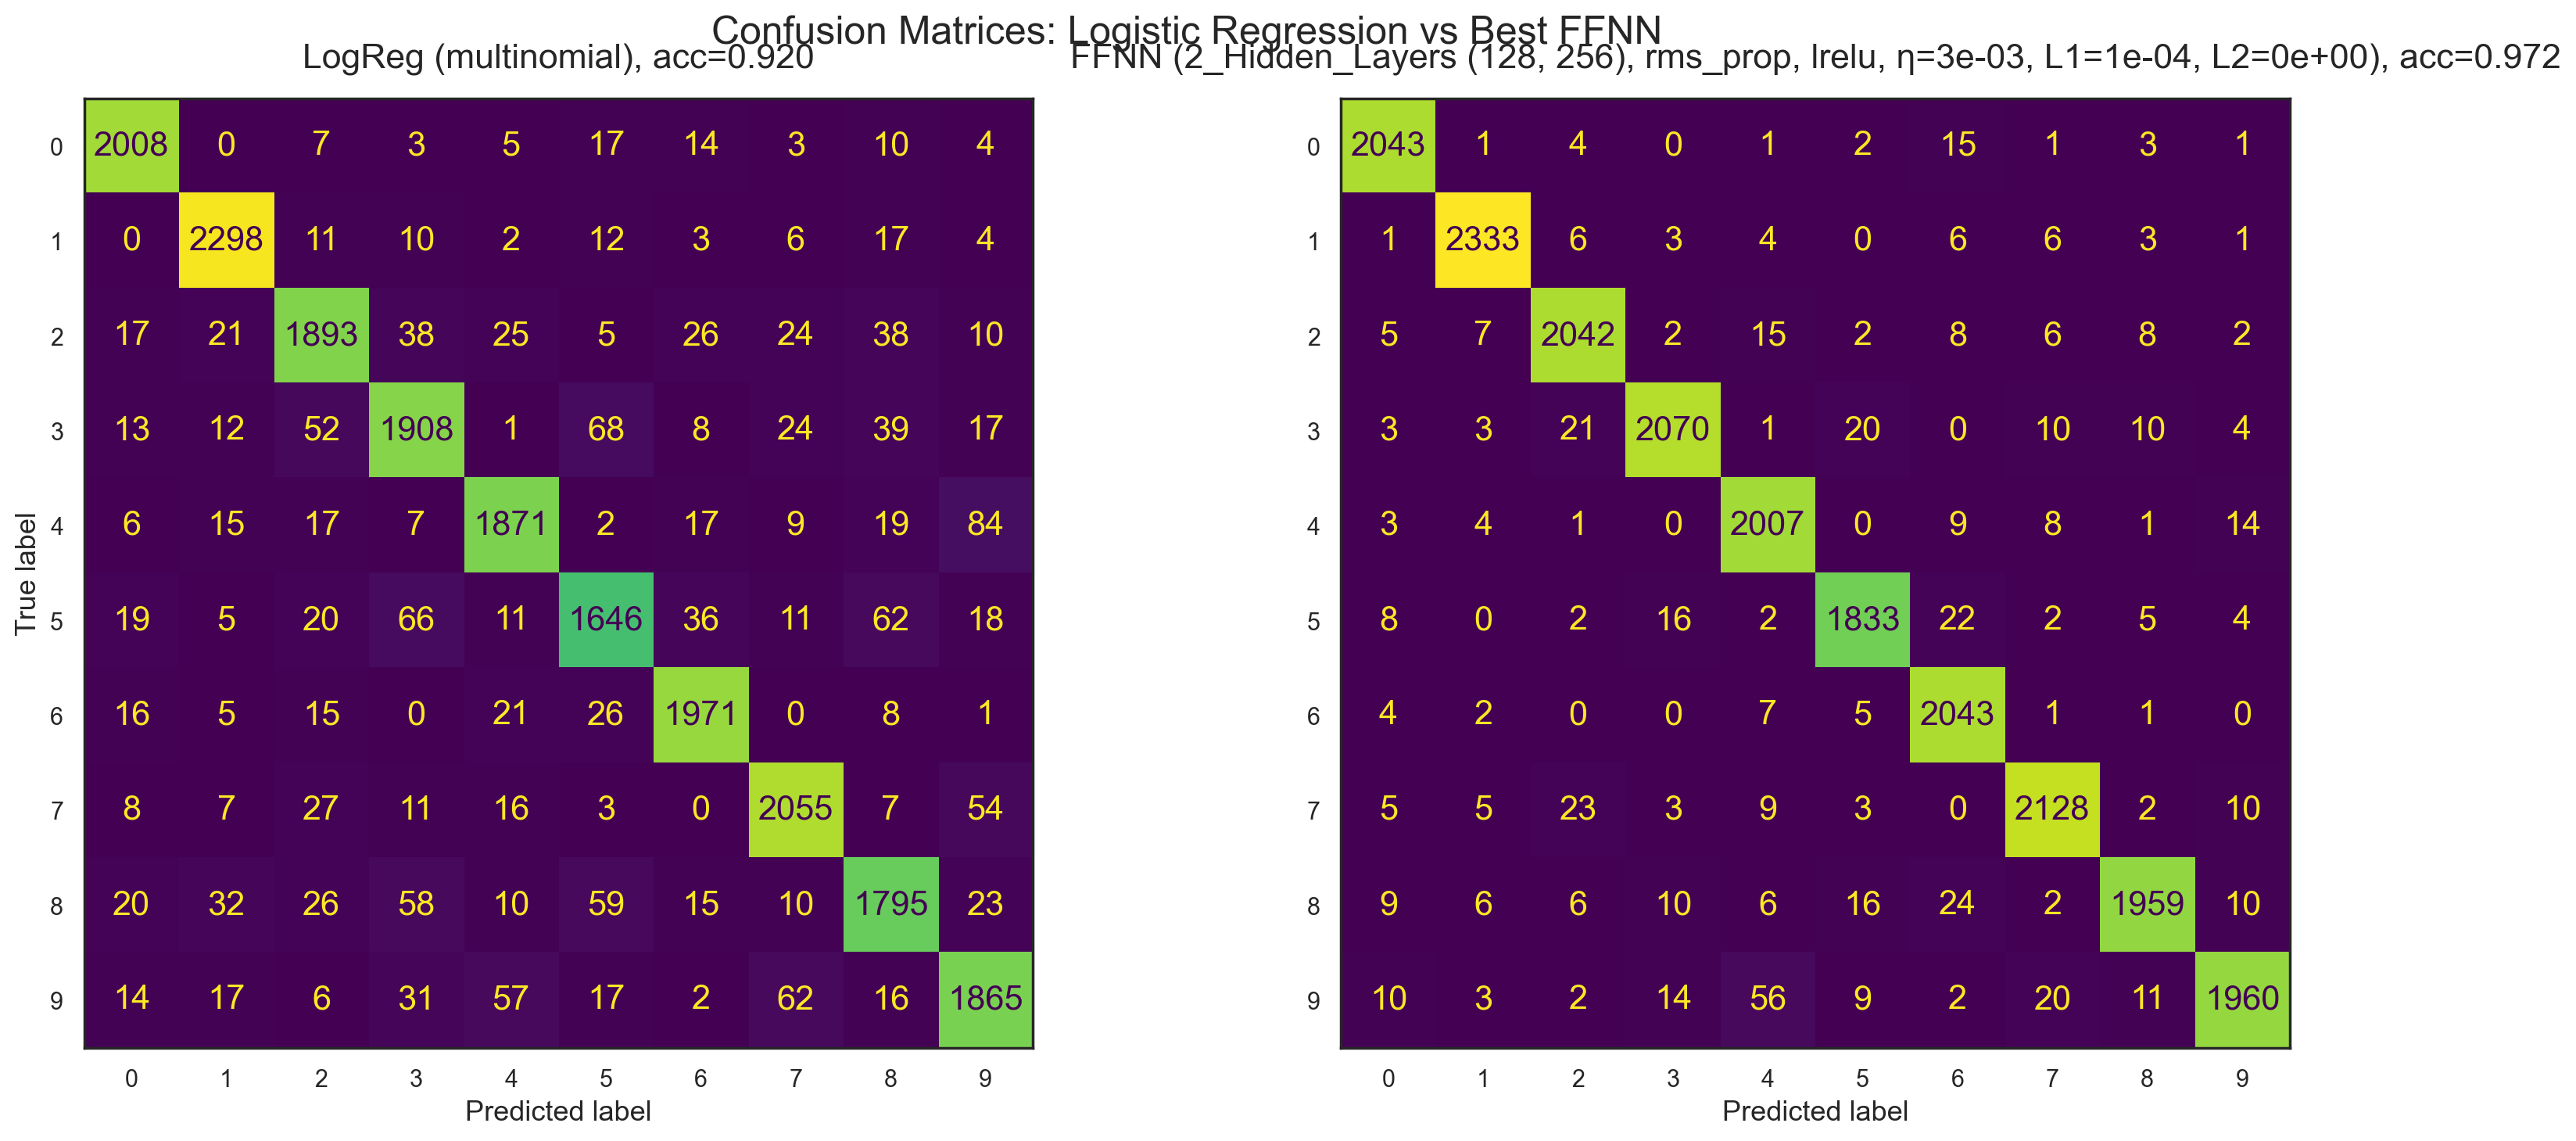

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_nn = confusion_matrix(y_test, y_pred_nn)

vmax = max(cm_lr.max(), cm_nn.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

titles = [
    f"LogReg (multinomial), acc={acc_lr:.3f}",
    f"FFNN ({best_arch}, {best_opt}, {best_act}, "
    f"η={best_eta:.0e}, L1={best_l1:.0e}, L2={best_l2:.0e}), acc={final_acc:.3f}"
]

for ax, cm, title in zip(axes, (cm_lr, cm_nn), titles):
    disp = ConfusionMatrixDisplay(cm, display_labels=np.arange(10))
    disp.plot(
        ax=ax,
        cmap="viridis",
        colorbar=False,
        values_format="d",
        im_kw={"vmin": 0, "vmax": vmax},
    )
    ax.set_title(title, fontsize=16, pad=14)
    ax.set_xlabel("Predicted label", fontsize=13)
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(False)

axes[0].set_ylabel("True label", fontsize=13)
axes[1].set_ylabel("")

plt.suptitle("Confusion Matrices: Logistic Regression vs Best FFNN", fontsize=18, y=1.02)
plt.show()


/var/folders/1r/krqcnpjn7ks4trq3gxh4kmpr0000gn/T/ipykernel_89961/1395755515.py:31: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1r/krqcnpjn7ks4trq3gxh4kmpr0000gn/T/ipykernel_89961/1395755515.py:31: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/beateovland/Documents/Fys-stk4155/FYS-STK4155-Project-2/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/beateovland/Documents/Fys-stk4155/FYS-STK4155-Project-2/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


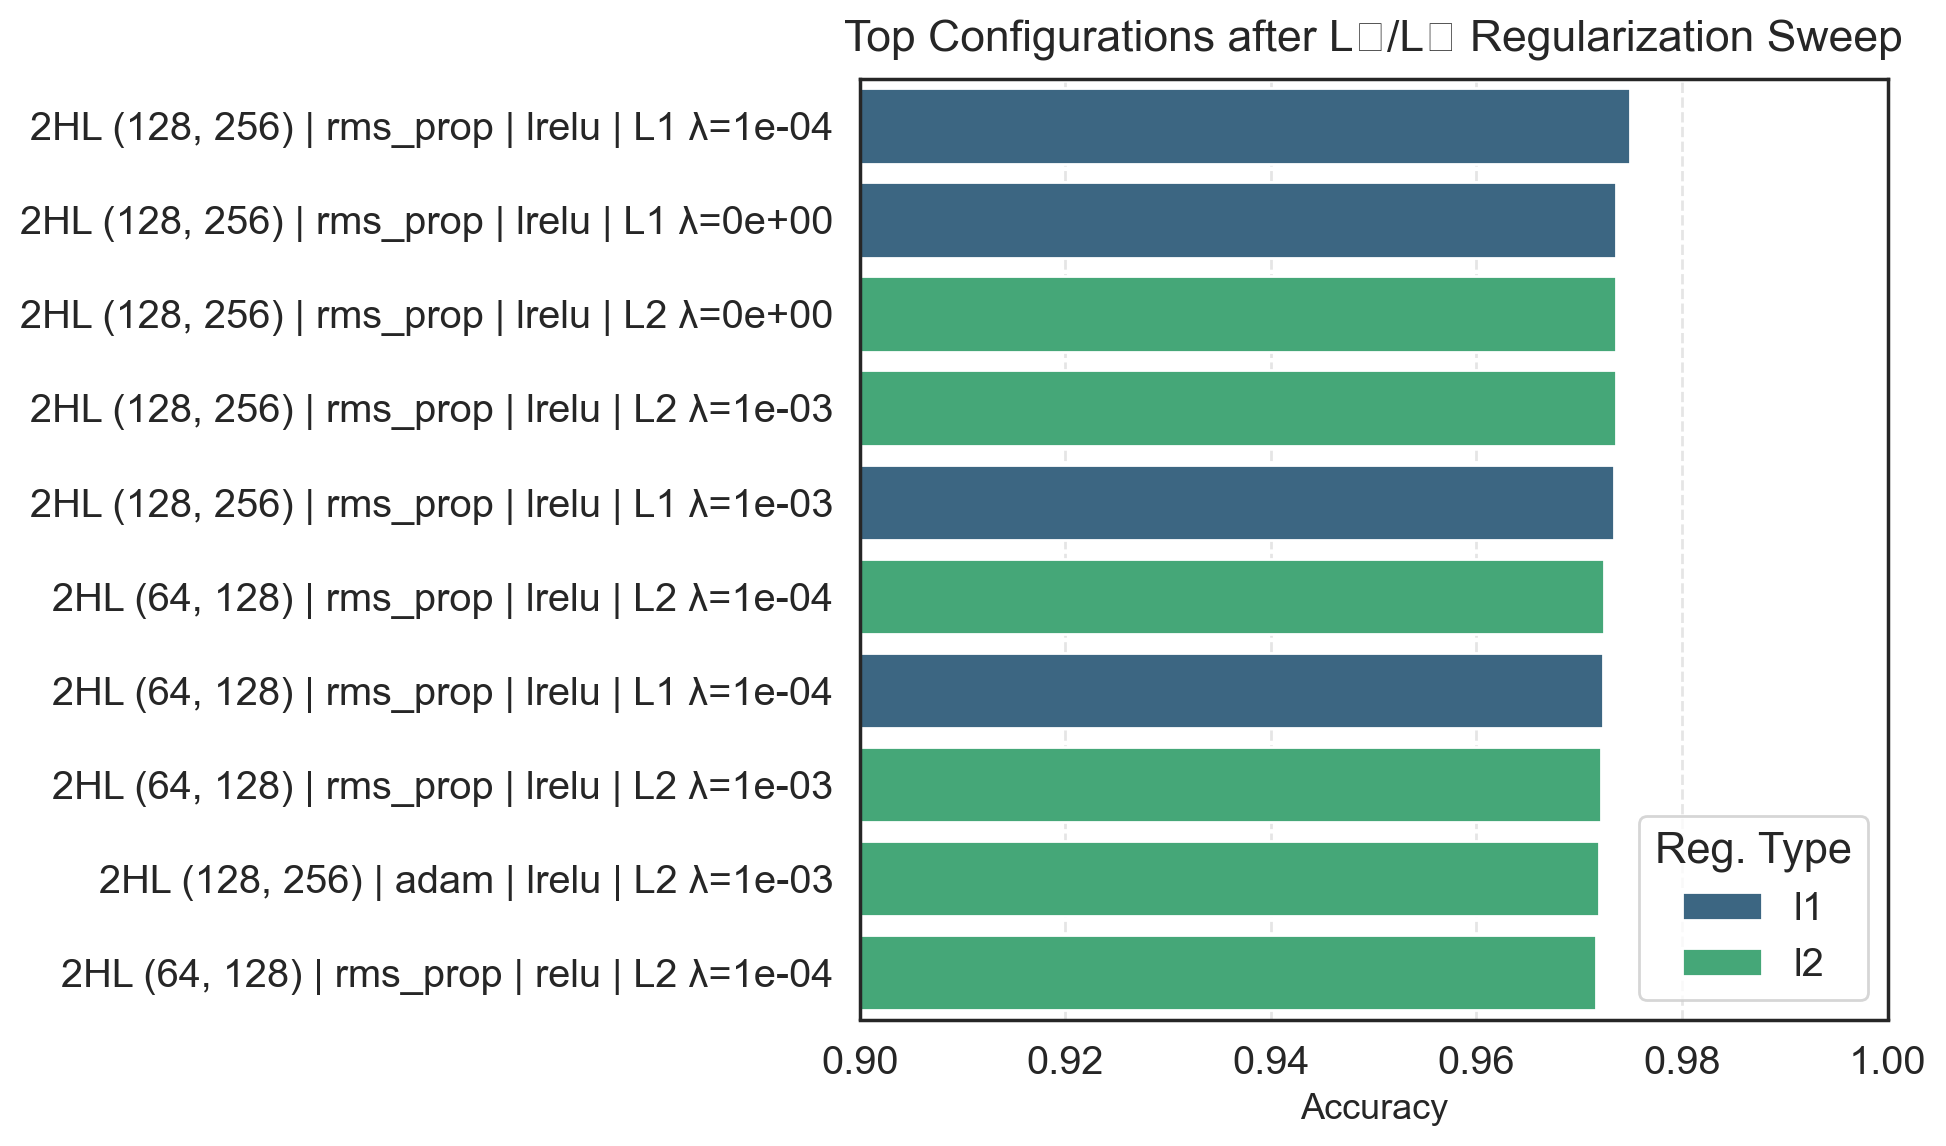

In [ ]:

# pick top 10 configs for clarity
plot_df = stageC_reg_df.head(10).copy()

# format λ column individually
plot_df["lambda_fmt"] = plot_df["lambda"].apply(lambda x: f"{x:.0e}")

# create readable labels for y-axis
plot_df["label"] = (
    plot_df["architecture"].str.replace("2_Hidden_Layers ", "2HL ", regex=False)
    + " | " + plot_df["optimizer"]
    + " | " + plot_df["activation"]
    + " | " + plot_df["reg_type"].str.upper()
    + " λ=" + plot_df["lambda_fmt"]
)

# make plot
plt.figure(figsize=(10, 6))
sns.barplot(
    y="label", x="accuracy", data=plot_df,
    hue="reg_type", dodge=False, palette="viridis"
)
plt.xlabel("Accuracy", fontsize=13)
plt.ylabel("")
plt.title("Top Configurations after L₁/L₂ Regularization Sweep", fontsize=16, pad=10)
plt.xlim(0.9, 1.0)
plt.legend(title="Reg. Type", loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
